# IT25103998 — Dissanayake D. M. A. S. K.
## Individual Preprocessing Task: Feature Engineering — Dimensionality Reduction (PCA)
**Dataset:** Chronic Kidney Disease (UCI ML Repository, id 336)
**Group:** 2026-Y2-S1-KU-56

This notebook demonstrates my individually assigned preprocessing technique — **dimensionality reduction
using Principal Component Analysis (PCA)** — applied to the CKD dataset (building on the scaled dataset
`IT25103996_scaled.csv` from Gunasekara's notebook, using all numeric+encoded features for a full-pipeline
view of dimensionality reduction alongside Senavirathna's feature selection).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
df = pd.read_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103998_pca_reduced.csv')
X = df.drop(columns=['class'])
y = df['class']
print(X.shape)

(399, 24)


### Why this technique is needed for this dataset
Even after feature selection, several clinical features (e.g. `hemo`, `pcv`, `rbcc`) are highly correlated
with each other because they measure related biological phenomena (anemia indicators). This redundancy adds
dimensionality without adding much new information. PCA compresses correlated features into a smaller set of
uncorrelated components while retaining most of the variance, which helps visualization and can speed up
model training.

In [ ]:
pca_full = PCA().fit(X)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance by first 10 components:", explained[:10].round(3))
print("Cumulative variance at 10 components:", cumulative[9].round(3))

Explained variance by first 10 components: [0.363 0.104 0.085 0.068 0.061 0.057 0.05  0.044 0.036 0.028]
Cumulative variance at 10 components: 0.896


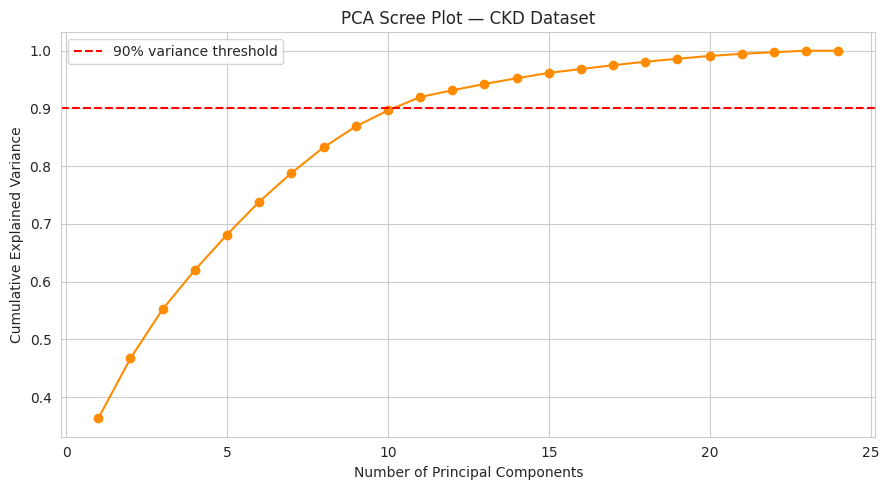

In [ ]:
# EDA Visualization 1: Scree plot / cumulative explained variance
plt.figure(figsize=(9,5))
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='darkorange')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot — CKD Dataset')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103998_pca_scree_plot.png', dpi=120)
plt.show()

**Interpretation:** Roughly 10-11 components are needed to retain 90% of the total variance in the
24-feature dataset — a meaningful reduction, though not a drastic one, which tells us the original features
are only moderately redundant (consistent with Senavirathna's finding that a handful of features dominate
in mutual-information terms while the rest still add some unique signal).

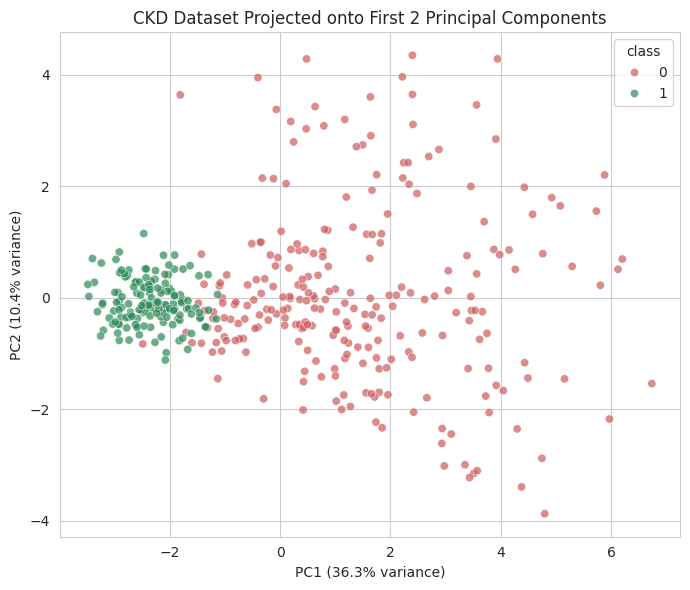

In [ ]:
# Fit PCA to 2 components purely for visualization of class separability
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(7,6))
palette = {0: 'indianred', 1: 'seagreen'} if set(y.unique()) <= {0,1} else {'ckd':'indianred','notckd':'seagreen'}
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1], hue=y, palette=palette, alpha=0.7)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('CKD Dataset Projected onto First 2 Principal Components')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103998_pca_2d_scatter.png', dpi=120)
plt.show()

**Interpretation:** Even with just the first two principal components, the `ckd` and `notckd` classes
form largely separate clusters — a strong early signal that the models built in Step 3 should be able to
achieve good separation on this dataset.

In [ ]:
# Final dimensionality-reduced dataset: keep enough components for 90% variance
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)
pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X)

df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['class'] = y.values
print(f"Reduced from {X.shape[1]} features to {n_components_90} principal components (90% variance retained)")
df_pca.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103998_pca_reduced.csv', index=False)
df_pca.head()

Reduced from 24 features to 11 principal components (90% variance retained)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,class
0,-1.104179,0.214270,0.088900,-0.412679,-0.207506,0.306436,0.610790,0.081132,-0.541224,0.137800,-0.302709,0
1,-0.242729,-0.204393,3.818381,-2.364896,0.253899,-0.632515,-0.697019,-0.792822,0.577544,0.275922,0.349307,0
2,2.239557,2.419660,-0.580659,-0.796443,-0.713555,-0.090536,-0.600267,-0.291338,0.647459,-0.028056,1.154153,0
3,2.943071,-0.675848,3.506301,0.334065,-1.859344,-0.930484,1.334323,-0.288809,0.115778,-0.402119,-0.250626,0
4,0.087588,-0.361571,0.876338,-0.530489,-0.013046,0.618566,0.542847,-1.007264,-0.023005,-0.310110,0.418082,0


### Summary
- **Technique:** Feature engineering via **dimensionality reduction (PCA)**.
- **Justification:** Several clinical features are correlated (anemia-related measurements), so PCA
  compresses the 24-feature scaled dataset into a smaller uncorrelated component set while retaining 90% of
  the variance, and a 2D projection already shows visibly separable CKD/notckd clusters.
- **Output:** `results/outputs/IT25103998_pca_reduced.csv` — dataset reduced from 24 features to
  the top principal components explaining 90% of variance.
- **Note for the group:** PCA (this notebook) and mutual-information feature selection (Senavirathna's
  notebook) are two alternative feature-engineering paths; the group pipeline keeps both as options so the
  Step 3 model-design phase can compare model performance on either representation.